# Audio Fingerprinting Pipeline: Step-by-Step Explanation and Visualization

This notebook explains the steps involved in this audio fingerprinting pipeline including:
- loading audio
- computing spectrograms
- detecting peaks
- generating fingerprints
- storing them in a database
- matching for recognition.

## Quick Overview of the Shazam Algorithm

Shazam's audio fingerprinting works by turning sound into a unique "fingerprint" that can be matched against a database of songs. Here's the gist:

1. **Audio to Spectrogram**: Convert the audio into a spectrogram using Short-Time Fourier Transform (STFT), which shows how frequencies change over time. This computes a 3d dataset with (time, frequency, amplitude)

2. **Find Peaks**: Identify key points (peaks) in the spectrogram where energy is high. These peaks are features that stand out from other frequencies like background noise.

3. **Create Fingerprints**: For each peak (called an "anchor"), pair it with nearby peaks within a time and frequency range (we're only using time here), then hash the combination (e.g., time difference and frequency difference) into a unique code. These fingerprints show us how the sound changes at specific moments in time, and the combination of many of these can be used to tell it apart from other sounds. Identical fingerprints, even if at different moments in the song, will generate identical hashes.

4. **Store and Match**: Save these hashes in a database with song IDs and timestamps. When you query a clip, generate its fingerprints and look for matches. The goal is to find a song that not only has many identical fingerprints but whose fingerprints are equally separated as those found in the recorded clip.

This makes recognition fast and reliable, handling variations like background noise or partial clips...hopefully

### Resources:

These are some of the articles and videos I read and watched on the topic, which sparked my curiosity.

- [The Five-Second Fingerprint: Inside Shazam’s Instant Song ID](https://towardsdatascience.com/the-five-second-fingerprint-inside-shazams-instant-song-id)

- [How Shazam Works (Probably!) - Computerphile](https://www.youtube.com/watch?v=RRsq9apr5QY)

- [But what is the Fourier Transform? A visual introduction.](https://www.youtube.com/watch?v=spUNpyF58BY)

- [Discrete Fourier Transform - Simple Step by Step](https://www.youtube.com/watch?v=mkGsMWi_j4Q)

The audio files I used in my experiments were obtained from the MUSAN audio collection. [MUSAN](https://openslr.org/17/) is a corpus of music, speech, and noise recordings supported by the National Science Foundation Graduate Research Fellowship under Grant No. 1232825 and by Spoken Communications.

```LaTeX
@misc{musan2015,
  author = {David Snyder and Guoguo Chen and Daniel Povey},
  title = {{MUSAN}: {A} {M}usic, {S}peech, and {N}oise {C}orpus},
  year = {2015},
  eprint = {1510.08484},
  note = {arXiv:1510.08484v1}
}
```


## 1. Import Required Libraries

In this step, we import the necessary Python libraries and modules for our audio fingerprinting pipeline. These include:

- `matplotlib.pyplot` for visualizing spectrograms and peaks
- `pathlib.Path` for handling file paths
- Custom modules from our `audio_processing` package: `load_audio` for audio loading
- `spectrogram` and `find_peaks` for computing spectrograms and detecting peaks
- Database-related functions: `connect`, `init_db` for database operations
- `generate_fingerprints` for creating unique fingerprints from peaks
- `persist_song_data` for storing song fingerprints in the database

These imports set up our environment to process audio files and perform fingerprinting operations.

In [60]:
# Import libraries for audio processing, visualization, and database operations
from pathlib import Path
import matplotlib.pyplot as plt

from audio_processing.audio import load_audio
from audio_processing.spectrogram import spectrogram, find_peaks
from config import DEFAULT_HOP_LENGTH, DEFAULT_N_FFT
from controllers.database import connect, init_db
from controllers.fingerprint import generate_fingerprints
from controllers.match_service import MatchService
from controllers.song_manager import persist_song_data



## 2. Load Audio Files

Here, we load WAV audio files from our dataset directory. It finds all .wav files in that directory and loads the first one as an example for demonstration.

The `load_audio` function reads the audio file, returning the audio signal (`y`) as a numpy array and the sample rate (`sr`) in Hz. This step prepares the raw audio data for further processing into a spectrogram.

I'll just focus on one example so we can visualize how the data is processed in each step.

In [22]:
# Specify the folder containing WAV files
wav_path = Path("data", "assets", "clean_wavs", "music-hd-0067.wav") # Let's get the 0067 file as an example
y_original, sr = load_audio(wav_path.as_posix())
print(f"Loaded {wav_path.name}, Sample Rate: {sr}, Audio Length: {len(y_original)/sr:.2f} seconds")

Loaded music-hd-0067.wav, Sample Rate: 22050, Audio Length: 89.78 seconds


## 3. Compute Spectrogram

In this step, we transform the loaded audio signal into a spectrogram using the Short-Time Fourier Transform (STFT). The spectrogram represents the audio in the time-frequency domain, showing how the frequency content changes over time.

We use default parameters: `n_fft=2048` (window size for FFT) and `hop_length=512` (overlap between windows). The result `S_db` is the spectrogram in decibels (dB), which compresses the dynamic range for better visualization and peak detection.

In [24]:
# Compute the spectrogram for the loaded audio
S_dB_original = spectrogram(y_original, n_fft=DEFAULT_N_FFT, hop_length=DEFAULT_HOP_LENGTH)
print(f"Spectrogram shape: {S_dB_original.shape}")
print(f"Min dB {S_dB_original.min()}")
print(f"Max dB {S_dB_original.max()}")

Spectrogram shape: (1025, 3867)
Min dB -80.0
Max dB 0.0


Looking at this spectrogram, we can see the song's acoustic fingerprint in visual form. Each horizontal line represents a frequency bin, and the vertical axis shows time progressing from left to right. The color intensity (brighter = higher energy) reveals where the song has strong spectral content.

Notice the distinct patterns: vertical streaks might indicate sustained notes or harmonics, while horizontal bands could show rhythmic elements or drum beats. These visual features are what make each song unique - no two songs will have exactly the same spectrogram pattern. This time-frequency representation captures the essence of the music, transforming audio waves into a visual map that our fingerprinting algorithm can analyze and match against.

We use "bins" rather than actual frequency or time values because the spectrogram is computed using Short-Time Fourier Transform (STFT), which divides the continuous audio signal into discrete time windows and frequency bands. Each bin represents a specific range of frequencies (e.g., 0-100 Hz, 100-200 Hz) and time segments, making the data discrete and computationally manageable for analysis and pattern recognition.

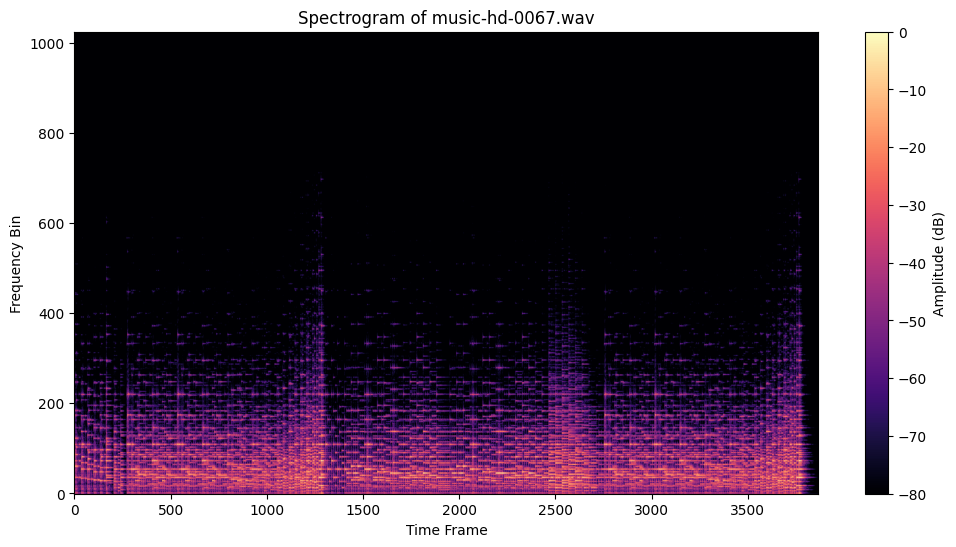

In [25]:
# Visualize the spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_dB_original, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram of {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

## 4. Find Spectrogram Peaks

Peaks are the key features in the spectrogram, obtained by finding local maxima in the amplitude of specific frequencies (frequency bins). Not all local maxima are relevant. We exclude low-energy noise and focus on prominent spectral features by applying a minimum amplitude threshold (`amp_min`).

The amplitude is measured in decibels (dB), where 0 dB represents the reference level, and negative values indicate signals below that level. Increasing `amp_min` towards 0 dB requires peaks to be louder, effectively filtering out more of the quieter spectral features. This reduces the total number of peaks detected, focusing only on the most prominent ones. So here we have a trade-off, between capturing enough distinctive features versus avoiding noise and irrelevant details. As you can see from the output below, even with this filter we find a large number of peaks.

In [26]:
# Find peaks in the spectrogram
amp_min = -60  # Minimum amplitude threshold for peak detection

peaks = find_peaks(S_dB_original, amp_min=amp_min)
print(f"Number of peaks detected: {len(peaks)}")

Number of peaks detected: 2279


If we overlay the detected peaks on the spectrogram we can see exactly where the significant spectral features occur in time and frequency space.

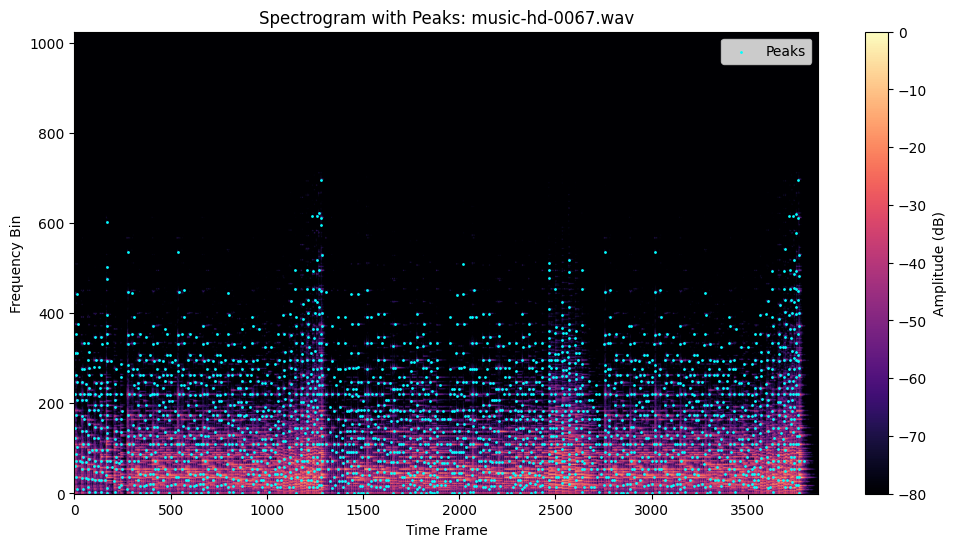

In [27]:
# Visualize peaks on the spectrogram
plt.figure(figsize=(12, 6))
times, freqs = zip(*peaks)
plt.scatter(times, freqs, s=1, c="cyan", label="Peaks")
plt.imshow(S_dB_original, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram with Peaks: {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.legend()
plt.show()

Instead of using a heatmap we can also look at these peaks in the 3D space. This is useful because it shows amplitude as a third dimension, so we can see how peak intensities vary across time and frequency.

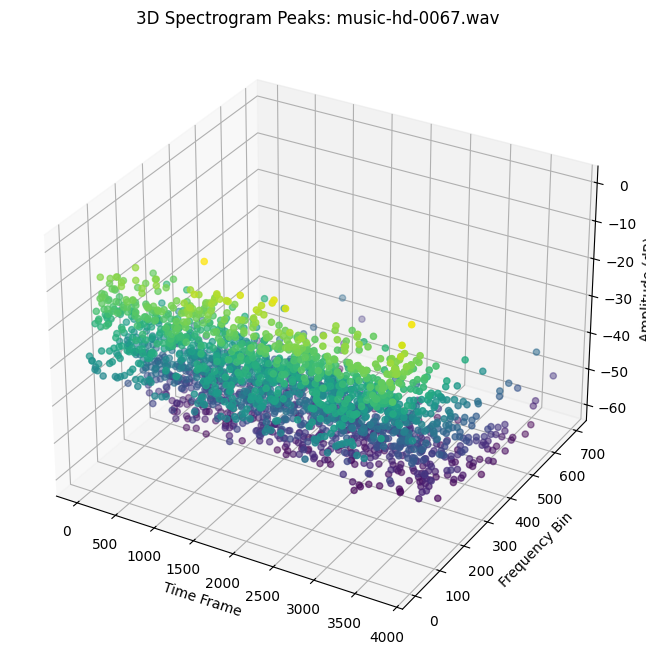

In [28]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
if peaks:
    times, freqs = zip(*peaks)
    amplitudes = S_dB_original[freqs, times]
    ax.scatter(times, freqs, amplitudes, c=amplitudes, cmap='viridis', s=20)
ax.set_xlabel('Time Frame')
ax.set_ylabel('Frequency Bin')
ax.set_zlabel('Amplitude (dB)')
ax.set_title(f'3D Spectrogram Peaks: {wav_path.name}')
plt.show()

## 5. Generate Fingerprints from Peaks

This is the step that creates the identifiable feature specific to the songs.
Fingerprints are unique identifiers created from the peaks. For each peak (anchor), we find nearby peaks within a certain window (I'm using the nearest 15 peaks) and compute the time difference and frequency difference. This data captures the song's unique frequency changes (how it changes and how quickly) and will be stored in the database for matching. To do so, these values are hashed into a unique code, along with the anchor's offset.

The `generate_fingerprints` function produces a list of (hash, offset, anchor frequency, target_time_bin, target_frequency_bin) tuples. Only the first two values are actually used to find the songs, but storing the full information allows us to visualize the fingerprints as the vectors they are.

In [16]:
# Generate fingerprints from peaks
original_fingerprints = generate_fingerprints(peaks)
print(f"Number of fingerprints generated: {len(original_fingerprints)}")
# Display a few example fingerprints
print("Example fingerprints:", original_fingerprints[:5])

Number of fingerprints generated: 12187
Example fingerprints: [('3915a7bcb3407cd1cd36', np.int64(2107), np.int64(0), np.int64(2124), np.int64(0)), ('72172c9e84431d0bb3f3', np.int64(2107), np.int64(0), np.int64(2136), np.int64(0)), ('cf9ae3f1bf2cb0d17a7a', np.int64(2107), np.int64(0), np.int64(2198), np.int64(0)), ('bb8951eca8e3a90d3064', np.int64(2107), np.int64(0), np.int64(2217), np.int64(0)), ('591f5f0e8fe64c3e5fd4', np.int64(2107), np.int64(0), np.int64(2237), np.int64(0))]


## 7. Persist Song Data to Database

To enable recognition, we store the song's fingerprints in a database.The song name is extracted from the file path (without extension).

The `persist_song_data` function inserts the song record and all its fingerprints into the database, associating each fingerprint with the song ID and its time offset. This creates our reference database for matching against unknown audio clips.

In [17]:
# Store fingerprints in the database
conn = connect()
init_db(conn)
song_name = wav_path.stem
persist_song_data(conn, song_name, original_fingerprints)
print(f"Persisted {len(original_fingerprints)} fingerprints for song '{song_name}' in the database.")

Persisted 12187 fingerprints for song 'music-hd-0067' in the database.


## 8. Match Fingerprints and Display Results

In this final step, we test the fingerprinting system by matching fingerprints against the database. The following code records audio from a microphone and runs it through the a similar pipeline: normalization, frequency filtering, peak detection and filtering, and finally fingerprint generation.

In [33]:
import time
from audio_pipeline import AudioFingerprintPipeline
from audio_processing.audio import record_audio

for i in range(3, 0, -1):
    print(f"\r--- Recording starts in {i} seconds ---")
    time.sleep(0.5)
print("Recording now...")
y_mic, sr_mic = record_audio(duration=7)
print("Recording done.")
print(f"Shape of input: {y_mic.shape}")

audio_pipeline = AudioFingerprintPipeline()
fingerprints_mic = audio_pipeline.run(y_mic)


--- Recording starts in 3 seconds ---
--- Recording starts in 2 seconds ---
--- Recording starts in 1 seconds ---
Recording now...
Recording done.
Shape of input: (154350,)


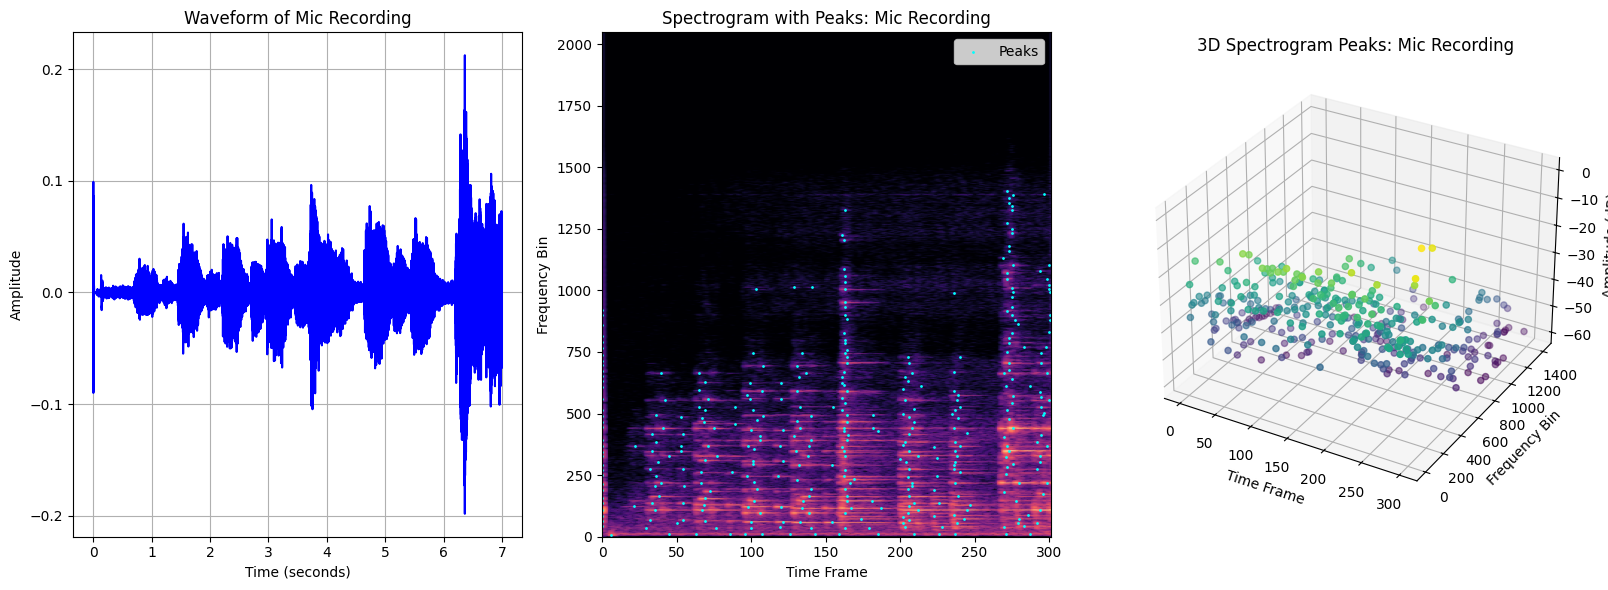

In [80]:
import numpy as np

S_dB_mic = audio_pipeline.checkpoints['spectrogram']
mic_peaks = audio_pipeline.checkpoints['peaks']

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

time_axis = np.arange(len(y_mic)) / sr_mic
ax1.plot(time_axis, y_mic, color='blue')
ax1.set_title("Waveform of Mic Recording")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

times, freqs = zip(*mic_peaks)
ax2.scatter(times, freqs, s=1, c="cyan", label="Peaks")
ax2.imshow(S_dB_mic, aspect="auto", origin="lower", cmap="magma")
ax2.set_title("Spectrogram with Peaks: Mic Recording")
ax2.set_xlabel("Time Frame")
ax2.set_ylabel("Frequency Bin")
ax2.legend()

if mic_peaks:
    times, freqs = zip(*mic_peaks)
    amplitudes = S_dB_mic[freqs, times]
    ax3.scatter(times, freqs, amplitudes, c=amplitudes, cmap='viridis', s=20)
ax3.set_xlabel('Time Frame')
ax3.set_ylabel('Frequency Bin')
ax3.set_zlabel('Amplitude (dB)')
ax3.set_title('3D Spectrogram Peaks: Mic Recording')

plt.tight_layout()
plt.show()

## 9. The Actual Search

In this section, we run the core matching algorithm to identify the song from the microphone recording. The key challenge is that we don't know which part of the original song was captured, it could be the beginning, middle, or end. Therefore, fingerprints from the mic recording might correspond to different time positions in the original song.

1. **Fingerprint Comparison**: For each fingerprint (hash) from the mic recording, we search the database for identical hashes. Each matching fingerprint in the database belongs to a specific song and has a recorded time offset (anchor_time) from the start of that song.

2. **Calculating Offsets**: For each match, we compute the time difference (offset) between the database fingerprint's anchor time and the mic fingerprint's anchor time:
   ```python
   offset = db_anchor_time - mic_anchor_time
   ```
   This offset represents how much the mic recording is "shifted" in time relative to the original song. If the mic captured the middle of the song, many fingerprints will have the same offset.

3. **Building the Offset Histogram**: For each song, we collect all these offsets and create a histogram showing how many fingerprints match at each possible time offset. The histogram reveals clusters of fingerprints that align at the same position in time.

4. **Scoring Songs**: The "score" for each song is the maximum value in its offset histogram. The larger the cluster of fingerprints in the same offset, the higher the song's score. This indicates the best temporal alignment between the mic recording and that song.

5. **Selecting the Match**: The song with the highest score is returned as the match. As a future improvement, if multiple songs have similar scores, the total number of fingerprints could be the tie breaker. 

These steps are implemented in the `match_fingerprints` function, which besides the final match, also returns the offset histogram so we can look at the distribution of matches. A sharp peak at one offset indicates that we found a strong match, while a bunch of scattered matches suggests noise or just poor alignment (weak match). Additionally, we could compare the match with the other runner-ups.

In [81]:
match_service = MatchService(conn)
matched_song, offset_histogram  = match_service.match_fingerprints(fingerprints_mic)
print(f"\nMatched Song: {matched_song}")


Matched Song: ('music-hd-0067', 159)


In the next cell we can take a look at the offset histogram for the match.

> Note: as the name suggests, the `frame_to_seconds` function lets us recalculate the actual time in seconds from the time bin of the fingerprints

 - The offset time frame with the most matches is: 6 with 159 matches, which should match 0.13931972789115646 seconds
 - The maximum offset time frame is: 7378 with 1 matches, which should match 171.3168253968254 seconds
 - The minimum offset time frame is: -228 with 3 matches, which should match -5.294149659863946 seconds

Top offsets by count: [(np.int64(6), 159), (np.int64(5), 33), (np.int64(432), 15), (np.int64(265), 12), (np.int64(1361), 9)]
Sum of top 3 offset counts: 207


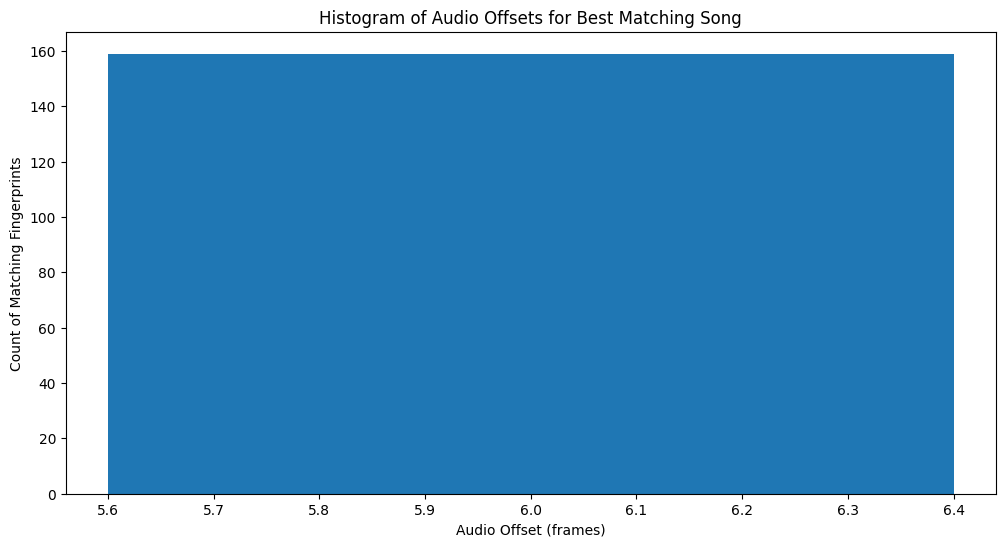

In [82]:
# Find the most common offset (by count, not by value)
from audio_processing.spectrogram import frame_to_seconds
from config import DEFAULT_SR

most_common_offset = max(offset_histogram.items(), key=lambda x: x[1])[0]
most_common_offset_seconds = frame_to_seconds(most_common_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The offset time frame with the most matches is: {most_common_offset} with {offset_histogram[most_common_offset]} matches, which should match {most_common_offset_seconds} seconds")

max_offset = max(offset_histogram.keys())
max_offset_seconds = frame_to_seconds(max_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The maximum offset time frame is: {max_offset} with {offset_histogram[max_offset]} matches, which should match {max_offset_seconds} seconds")

min_offset = min(offset_histogram.keys())
min_offset_seconds = frame_to_seconds(min_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The minimum offset time frame is: {min_offset} with {offset_histogram[min_offset]} matches, which should match {min_offset_seconds} seconds")

# Show the top 5 offsets by count
sorted_offsets = sorted(offset_histogram.items(), key=lambda x: x[1], reverse=True)
print("\nTop offsets by count:", sorted_offsets[:5])

top_three_offsets = sorted_offsets[:3]

# Total count of matched fingerprints within the top 3 most common offsets
sum_of_top_three = sum(count for offset, count in top_three_offsets)
print(f"Sum of top 3 offset counts: {sum_of_top_three}")

plt.figure(figsize=(12, 6))
plt.bar([offset for offset, count in sorted_offsets[:1]],
        [count for offset, count in sorted_offsets[:1]])
plt.title("Histogram of Audio Offsets for Best Matching Song")
plt.xlabel("Audio Offset (frames)")
plt.ylabel("Count of Matching Fingerprints")
plt.show()

Strategically I'm using a recording of the start of the song I chose so I can also provide a visualization of the fingerprints in the mic recording that were found in the database for the right song, as well as highlight the fingerprints in the actual original audio that were found in the mic recording.

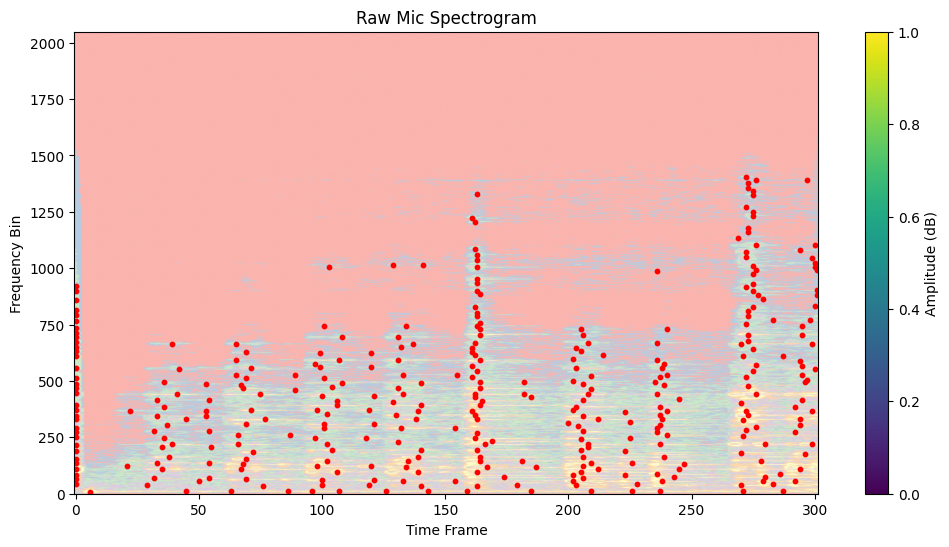

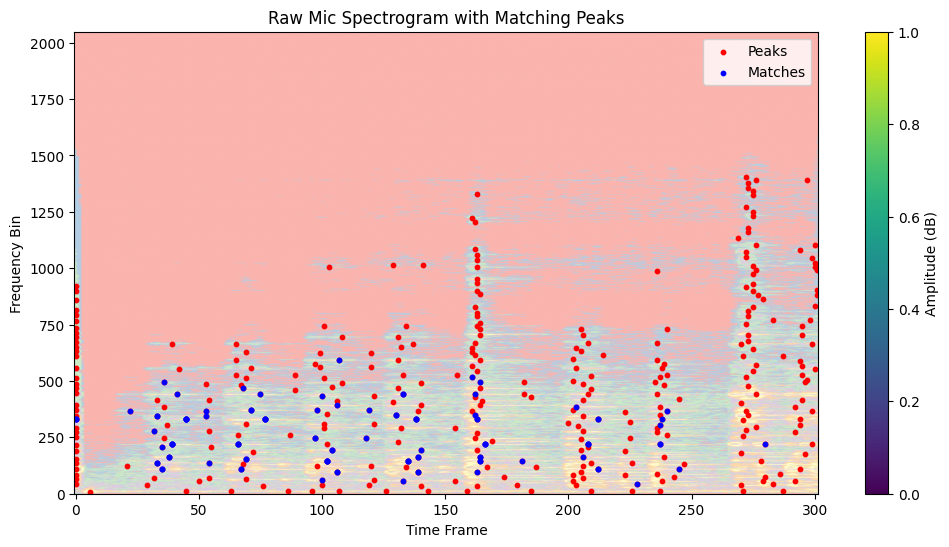

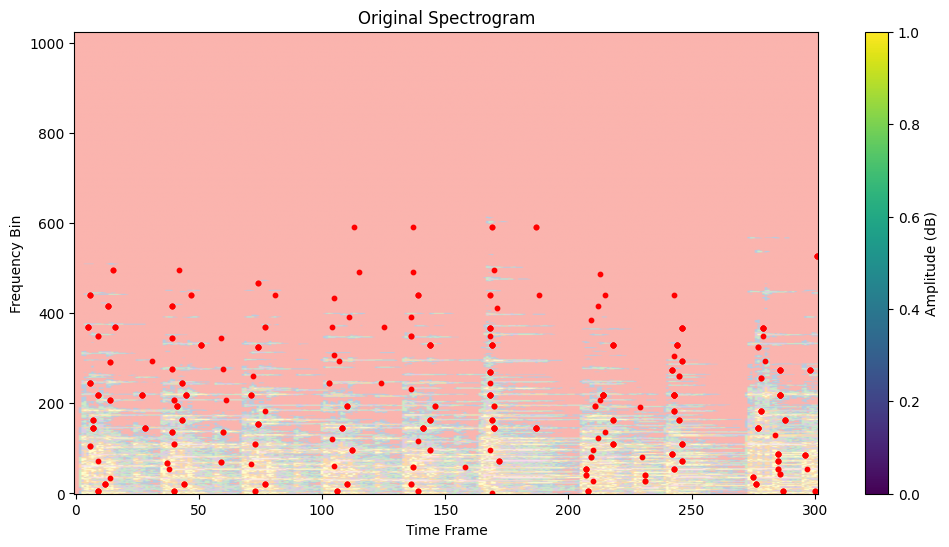

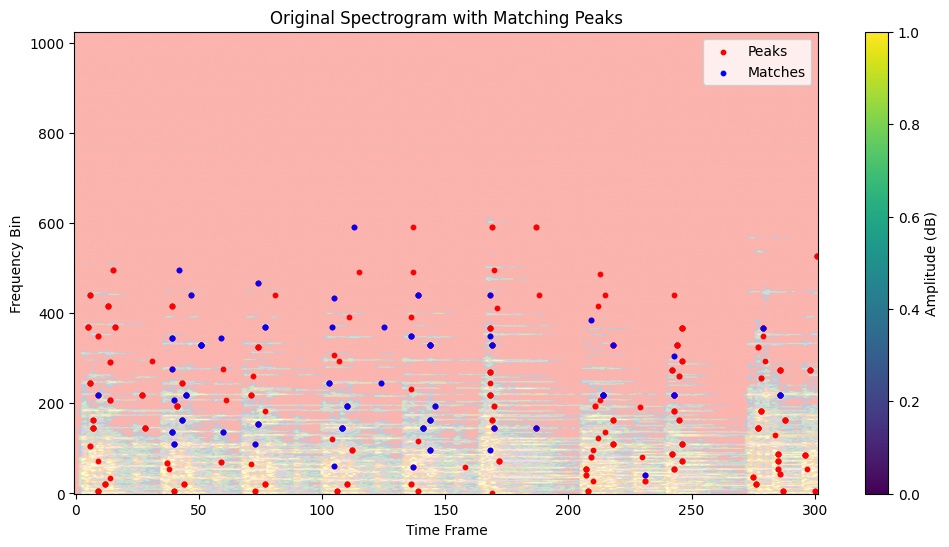

In [92]:
mic_and_audio_fps_intersection = match_service.get_matching_fingerprints_in_song("music-hd-0067", fingerprints_mic)

hashes_matching = {fp[0] for fp in mic_and_audio_fps_intersection}
mic_matching_peaks = [(t1, f1) for hash, t1, f1, t2, f2 in fingerprints_mic if hash in hashes_matching]

curr = conn.cursor()
curr.execute("""SELECT hash, anchor_time, anchor_freq, target_time, target_freq
             FROM fingerprints 
             LEFT JOIN songs ON (songs.id = fingerprints.song_id) 
             WHERE song_id=(SELECT id FROM songs WHERE name=?) 
             AND anchor_time  <= ?""", (song_name, mic_time_frames))
original_fingerprints = curr.fetchall()
original_all_peaks = [(t1, f1) for hash, t1, f1, t2, f2 in original_fingerprints]
original_matching_peaks = [(t1, f1) for hash, t1, f1, t2, f2 in original_fingerprints if hash in hashes_matching]

mic_time_frames = S_dB_mic.shape[1]
S_dB_original_slice = S_dB_original[:, :mic_time_frames]

plt.figure(figsize=(12, 6))
plt.imshow(S_dB_mic, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*mic_peaks), s=10, c="red", label="Peaks")
plt.colorbar(label="Amplitude (dB)")
plt.title("Raw Mic Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(S_dB_mic, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*mic_peaks), s=10, c="red", label="Peaks")
plt.scatter(*zip(*mic_matching_peaks), s=10, c="blue", label="Matches")
plt.colorbar(label="Amplitude (dB)")
plt.title("Raw Mic Spectrogram with Matching Peaks")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(S_dB_original_slice, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*original_all_peaks), s=10, c="red", label="Peaks")
plt.colorbar(label="Amplitude (dB)")
plt.title("Original Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(S_dB_original_slice, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*original_all_peaks), s=10, c="red", label="Peaks")
plt.scatter(*zip(*original_matching_peaks), s=10, c="blue", label="Matches")
plt.colorbar(label="Amplitude (dB)")
plt.title("Original Spectrogram with Matching Peaks")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.legend()
plt.show()

An exploration and visualization of an ideal scenario where the input matches 100% identically can be seen in the other notebook: [perfect_match_histograms.ipynb](perfect_match_histograms.ipynb).